- summer-average (JJA) SST and anomaly for each historical year.  
 
####  High PMM and neutral ENSO:
- 1993 3 (1978-2008) x
- 1994 3 (1979-2009)
- 2018 5 (2003-2033)
- 2019 4 (2004-2034)
Add
- Add 2015 7        PMM            Very Strong 
#### Low PMM and neutral ENSO and at least 1 TC:
- 1984 0 (1969-1999)
- 2005 1 (1990-2020) x
- 2008 0 (1993-2023)
- 2012 0 (1997-2027) x
Add
- 1998  0                      Strong La Nina
- 1999  1                      Strong La Nina


Ming Ge Feb. 2025

In [1]:
import glob
import os
from pathlib import Path
import numpy as np
import xarray as xr
 
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
 
import cartopy.crs as ccrs
import cartopy.feature as cfeature

In [2]:
def ax_coastlines_country(ax_s):
    ax_s.coastlines(linewidths=0.5)
    ax_s.add_feature(cfeature.NaturalEarthFeature(category='cultural',
                                           name='admin_0_countries',
                                           scale='10m',
                                           facecolor='none',
                                           edgecolor='black',                                      linewidth=0.2))

def plot_sst_p8(sst, levels, title_s, c_map):
    proj = ccrs.Robinson(central_longitude=180)
    fig, axs = plt.subplots(2, 4, figsize=(30,6), dpi=200, subplot_kw={'projection':proj})
     
    axs = axs.flatten()
     
    for col in range(8):
        #im = axs[col].contour(sst.longitude, sst.latitude, sst[col],
        #    colors='black',levels=levels[::2], linewidths=0.5,
        #    transform=ccrs.PlateCarree())
        imf = axs[col].contourf(sst.longitude, sst.latitude, sst[col],
            cmap = c_map, levels=levels, extend='both',
            transform=ccrs.PlateCarree())

        # draw gridlines 
        axs[col].gridlines()

        # mask land
        axs[col].add_feature(cfeature.LAND, facecolor='lightgrey', zorder=1) 

        
        # draw box of Niño 3.4 (5N-5S, 170W-120W): PPM (20°S-30°N, 175°E-85°W) 
        axs[col].add_patch(mpatches.Rectangle(xy=[175, -20], width=100, height=50,
                                facecolor='None', edgecolor='k', lw = 2,
                                transform=ccrs.PlateCarree()))

        # Draw the coastines for each subplot
        ax_coastlines_country(axs[col])
        
        # Title each subplot with the name of the model
        axs[col].set_title(title_s[col])

    # Add a big title at the top
    plt.suptitle('mean SST (JJA)  ')

    # add common colarbar
    fig.colorbar(imf, ax=axs.ravel().tolist())  


#### Read SST (JJA) of ERA5 

In [ ]:
%%time

year_tc = ['1993', '1994', '2018', '2019', 
           '1984', '2005',  '2008', '2012']
 
n_tc = len(year_tc)

dir_sst = '/glade/campaign/collections/rda/data/d633000/e5.oper.an.sfc/'
month_1d = ['06', '07', '08']

ct = 0
is_first = True
for year in year_tc:
    print(year)
    for month_s in month_1d:
        yyyymm = str(year) + month_s
        if month_s == '06':
            flnm = dir_sst  + yyyymm + '/e5.oper.an.sfc.128_034_sstk.ll025sc.'+yyyymm+'0100_'+yyyymm+'3023.nc'
        elif month_s == '07' or  month_s == '08':
            flnm = dir_sst  + yyyymm + '/e5.oper.an.sfc.128_034_sstk.ll025sc.'+yyyymm+'0100_'+yyyymm+'3123.nc'
              
        with  xr.open_dataset(flnm) as ds:
            sstk_0 = ds.SSTK.mean(dim="time")
             
            if is_first == True:
                # Expand to 3D by adding a new first dimension 'case' of size n_case
                sstk_tmp = sstk_0.expand_dims({"case": year_tc})
                # sstk_tmp is read only
                sstk_3d = sstk_tmp.copy()
                is_first = False
               
        if month_s == month_1d[0]:
            sstk_3d[ct] = sstk_0.data
        else:
            sstk_3d[ct] = sstk_3d[ct].data + sstk_0.data
        
        print(ct,flnm) 
     
    ct += 1  

sstk_3d = sstk_3d/float(len(month_1d))

#### 1.1 SST of summer-average (JJA) for each historical year

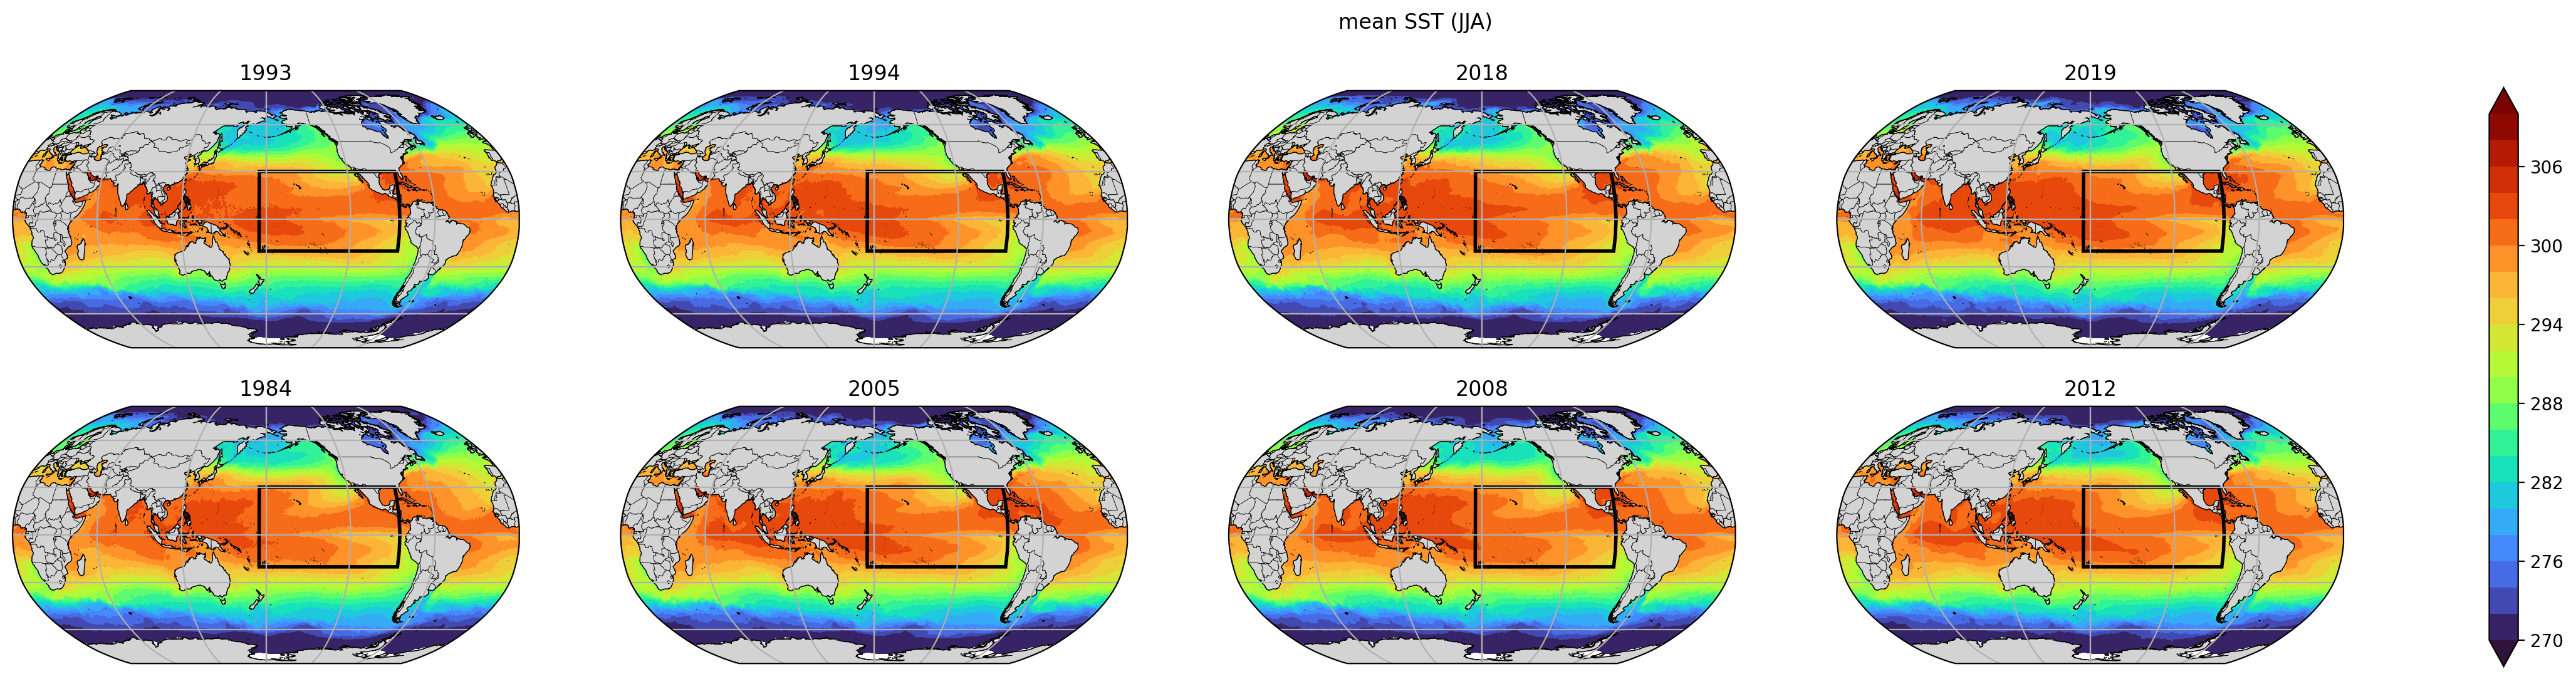

In [12]:
levels = np.linspace(270, 310, num=21)
plot_sst_p8(sstk_3d, levels, year_tc, 'turbo')

#### 1.2 SST anomaly of summer-average (JJA) for each historical year

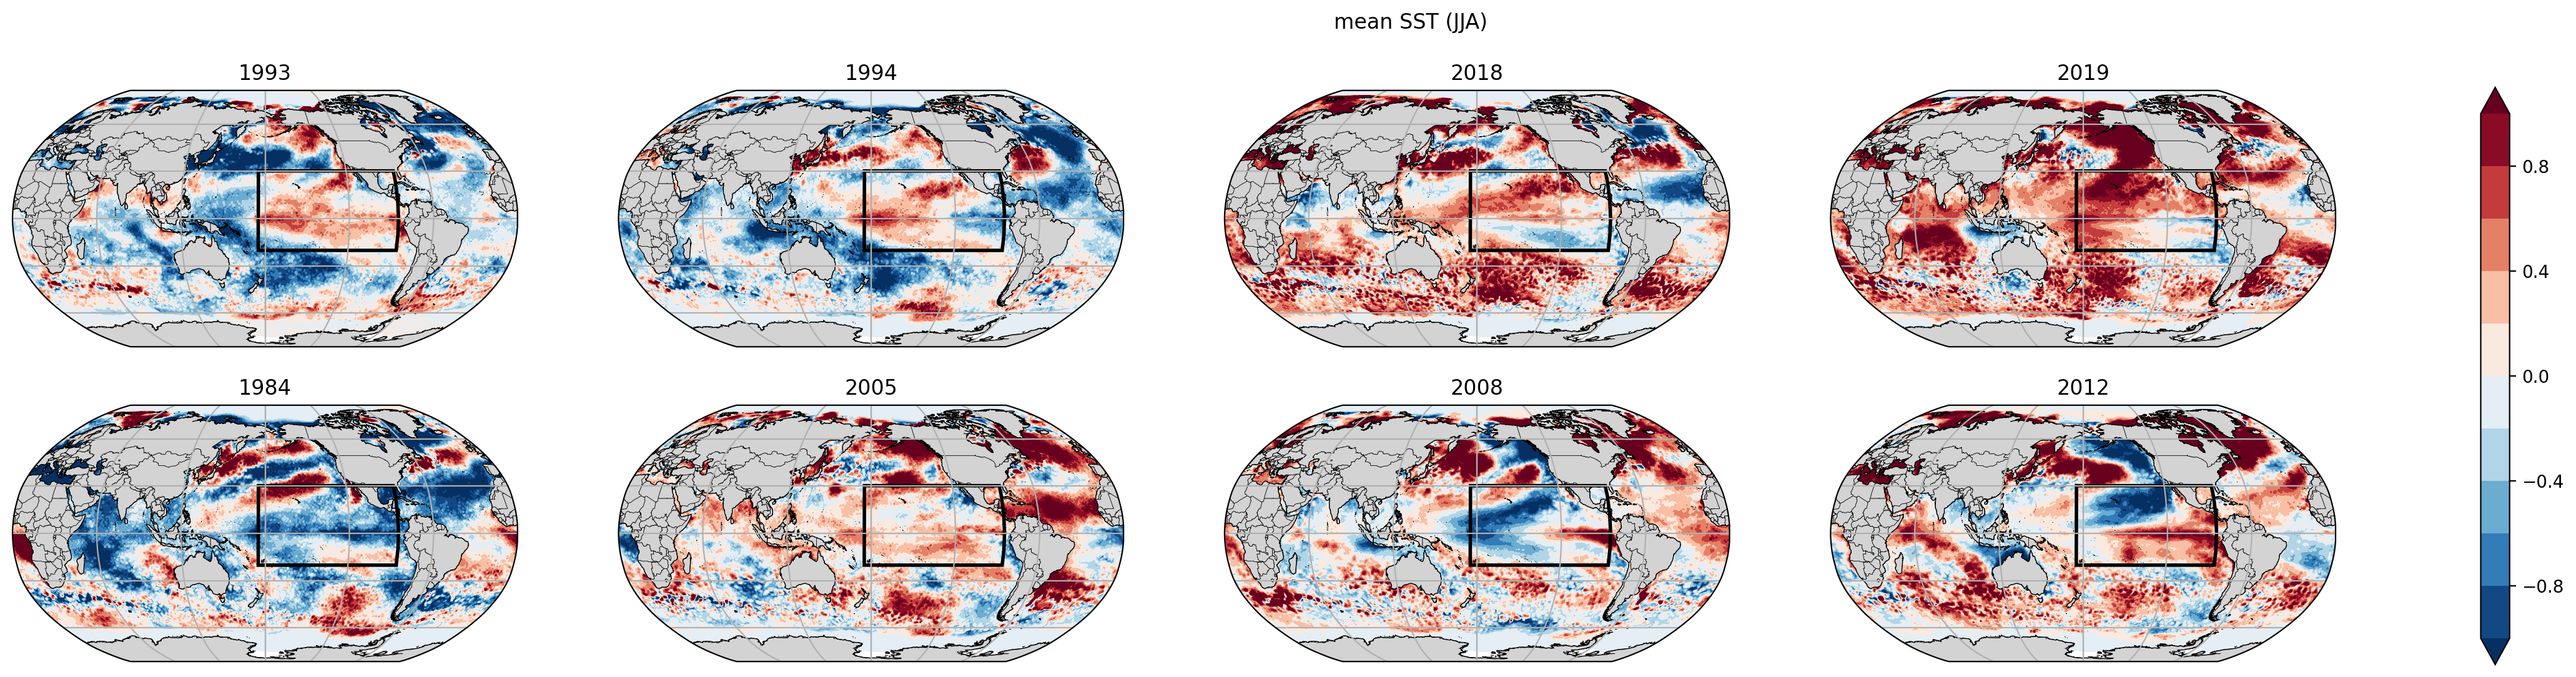

In [16]:
flnm_c = '/glade/campaign/mmm/c3we/mingge/ERA5/sst_jja_1980-2020_cli.nc'
with xr.open_dataset(flnm_c) as ds:
    sst_cli = ds.SSTK 

sst_dif = (sstk_3d-sst_cli)
levels = np.linspace(-1, 1, num=11)
plot_sst_p8(sst_dif, levels, year_tc, 'RdBu_r')

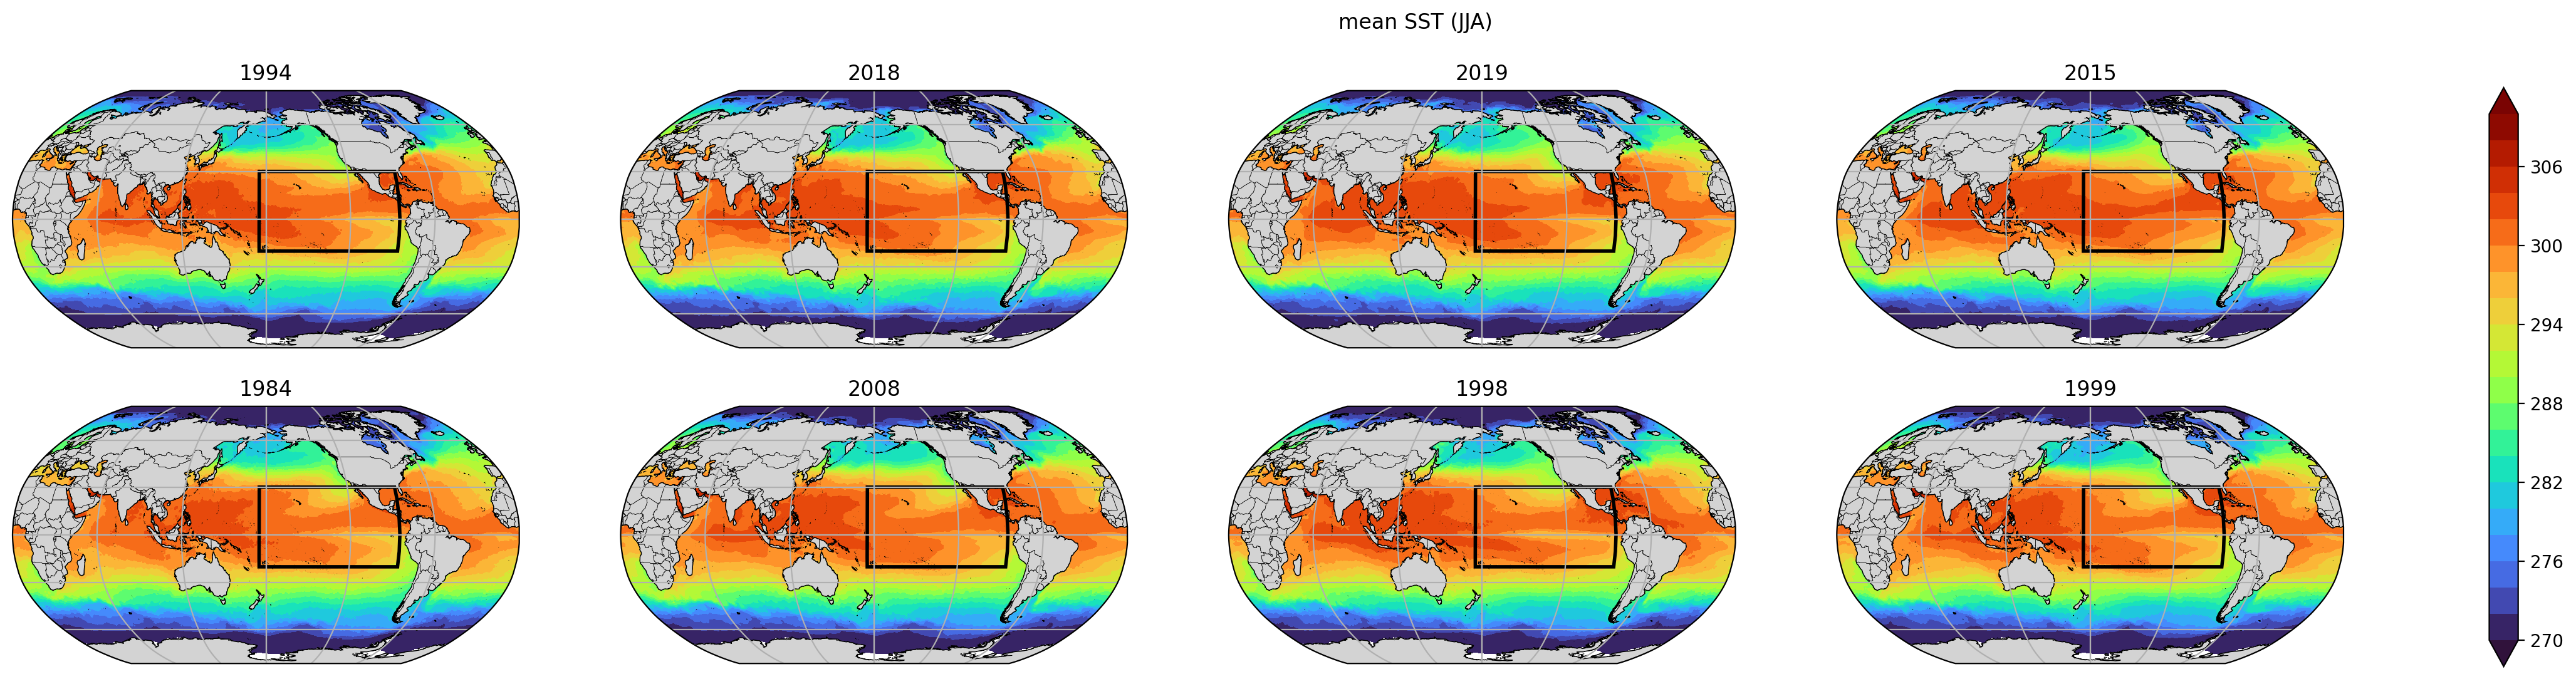

In [22]:
levels = np.linspace(270, 310, num=21)
plot_sst_p8(sstk_3d, levels, year_tc, 'turbo')

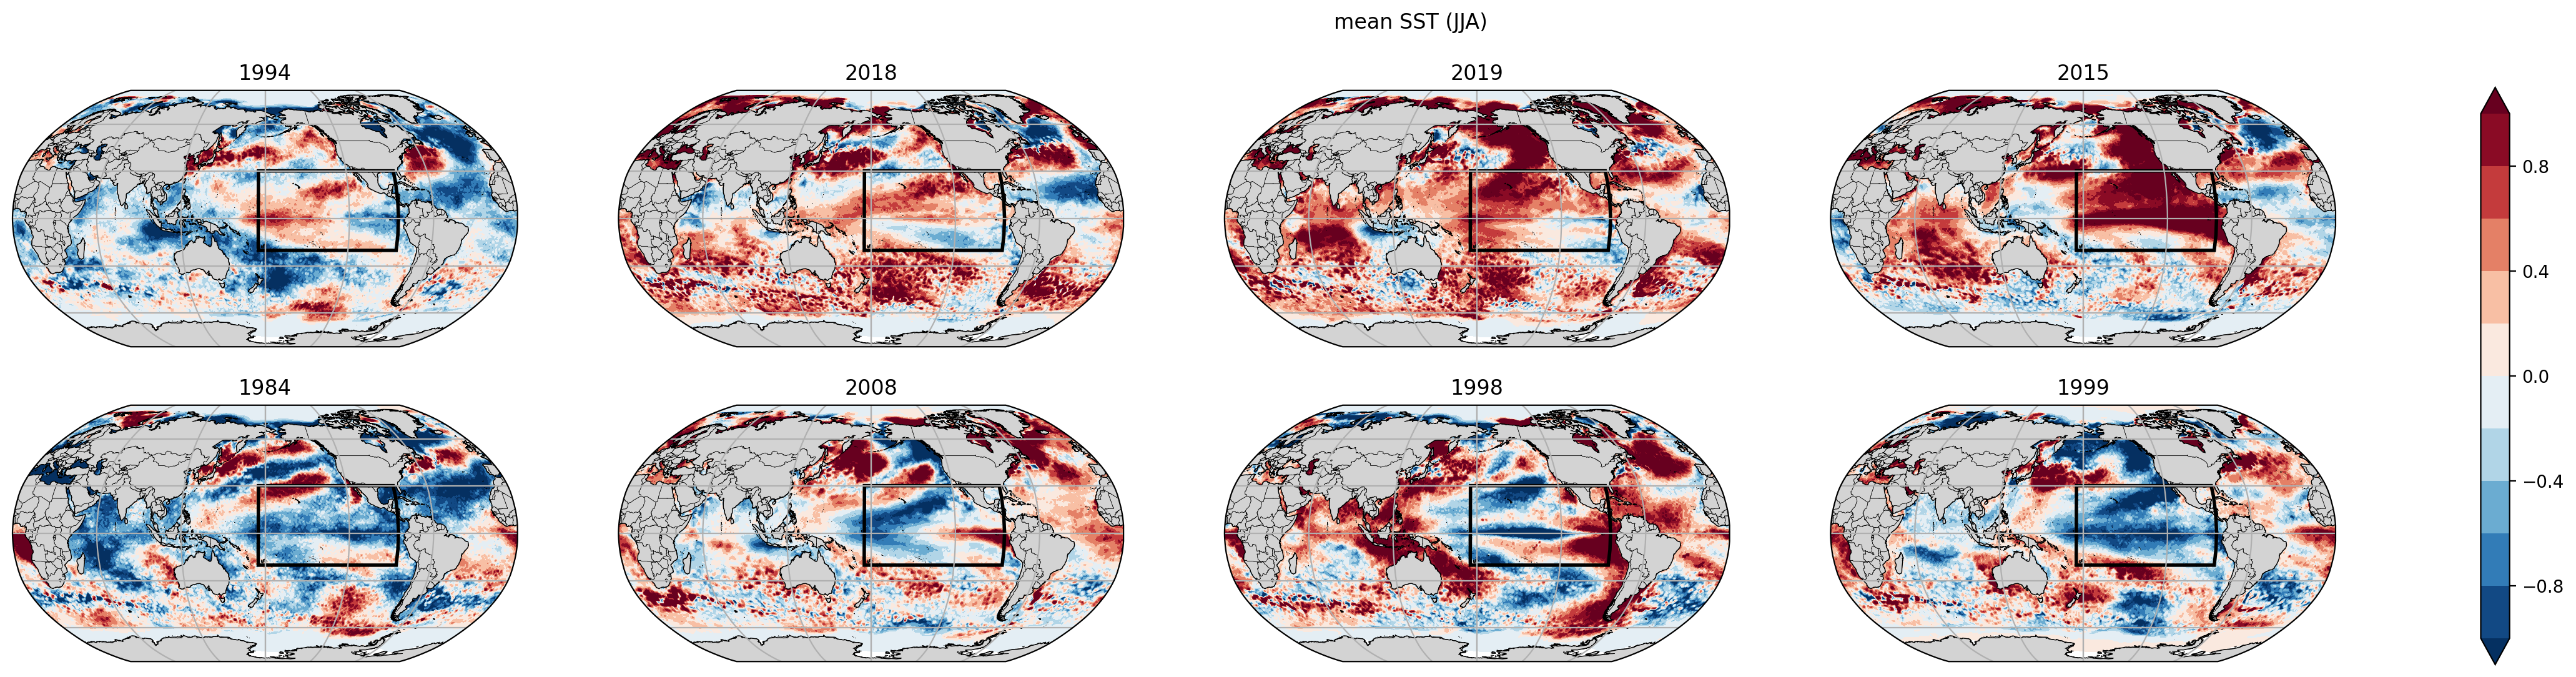

In [23]:
flnm_c = '/glade/campaign/mmm/c3we/mingge/ERA5/sst_jja_1980-2020_cli.nc'
with xr.open_dataset(flnm_c) as ds:
    sst_cli = ds.SSTK 

sst_dif = (sstk_3d-sst_cli)
levels = np.linspace(-1, 1, num=11)
plot_sst_p8(sst_dif, levels, year_tc, 'RdBu_r')